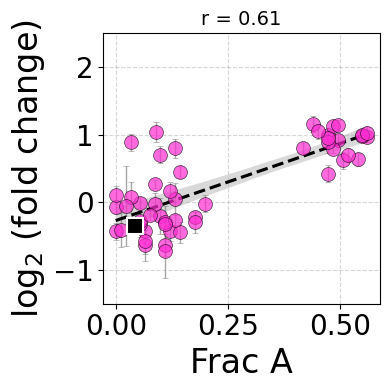

  Saved: nardini_Frac A_raw (r = 0.61)


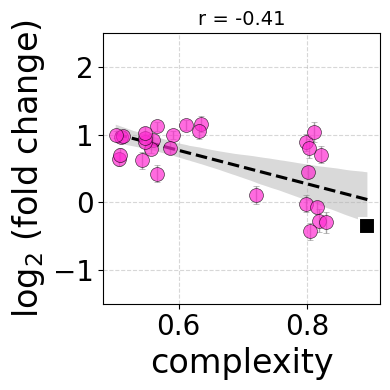

  Saved: sparrow_complexity (r = -0.41)


In [ ]:
## plot correlations for one template - Frac A and complexity only

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Load data
df1 = pd.read_csv('/../../Data/Figure_5/sequencing_data_all.csv')
results_df = pd.read_csv('/../../Data/Figure_5/heatmap_r_mean_clustered.csv')

# Define row order and colors
row_order = [
    'syn_LEA_1',
    'At2g46140_tile7',
    'TgL_8x',
    'Os_LEA_or3__Kappa_up_2_',
    'CAHS_68135_tile4',
    'A0A438HAK2',
    'Asyn_isoform_5',
    'A0A1U8F7A1',
    'Os_LEA_or6',
    'Os_LEA_or4',
    'A0A4D6M434',
]

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    return LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n)))

truncated_spring = truncate_colormap(plt.cm.spring, 0.10, 0.90)
colors = {origin: truncated_spring(i / (len(row_order) - 1)) for i, origin in enumerate(row_order)}

# Calculate weighted LFC for reps 1-3
lfc_cols = sorted([c for c in df1.columns if c.startswith('log2FoldChange_rep')
                   and c[-1] in ['1', '2', '3']])
se_cols = sorted([c for c in df1.columns if c.startswith('lfcSE_rep')
                  and c[-1] in ['1', '2', '3']])

lfc_data = df1[lfc_cols].values
se_data = df1[se_cols].values
weights = 1 / (se_data ** 2)

df1['weighted_log2FC'] = np.nansum(weights * lfc_data, axis=1) / np.nansum(weights, axis=1)
df1['pooled_SE'] = 1 / np.sqrt(np.nansum(weights, axis=1))

plt.rcParams['svg.fonttype'] = 'none'

# --- Settings ---
target_base = 'At2g46140_tile7'
target_features = ['nardini_Frac A_raw', 'sparrow_complexity']  # exact column names from results_df
min_n = 6
y_min, y_max = -1.5, 2.5

# Get the r_mean values for this template from the wide-format results_df
template_row = results_df[results_df['base_origin'] == target_base]
if template_row.empty:
    raise ValueError(f"'{target_base}' not found in results_df")

original_id = f"original_sequence_-_{target_base}"
original_row = df1[df1['Sequence_ID'] == original_id]

for feat in target_features:
    if feat not in results_df.columns:
        print(f"  Skipping {feat}: not found in results_df columns")
        continue
    if feat not in df1.columns:
        print(f"  Skipping {feat}: not found in df1 columns")
        continue
    if original_row.empty or pd.isna(original_row[feat].values[0]):
        print(f"  Skipping {feat}: no WT value")
        continue

    r_mean = template_row[feat].values[0]

    original_value = original_row[feat].values[0]
    lower_bound, upper_bound = original_value * 0.93, original_value * 1.07

    plot_df = df1[
        ((df1['base_origin'] == target_base) | (df1['Sequence_ID'] == original_id)) &
        ((df1['Sequence_ID'] == original_id) | ((df1[feat] < lower_bound) | (df1[feat] > upper_bound)))
    ].dropna(subset=[feat, 'weighted_log2FC', 'pooled_SE'])

    if plot_df.shape[0] < min_n:
        print(f"  Skipping {feat}: fewer than {min_n} points after filtering")
        continue

    fig, ax = plt.subplots(figsize=(4, 4))

    ax.errorbar(plot_df[feat], plot_df['weighted_log2FC'], yerr=plot_df['pooled_SE'],
                fmt='o', color=colors.get(target_base, 'gray'), alpha=0.7, ecolor='gray',
                elinewidth=1, capsize=2, markeredgecolor='black', markeredgewidth=0.5,
                markersize=10)

    wt_se = original_row['pooled_SE'].values[0] if pd.notna(original_row['pooled_SE'].values[0]) else 0
    ax.errorbar(original_row[feat], original_row['weighted_log2FC'], yerr=wt_se,
                fmt='s', color='black', markersize=12, markeredgecolor='white',
                markeredgewidth=1.5, zorder=5)

    sns.regplot(x=feat, y='weighted_log2FC', data=plot_df, scatter=False, ci=95,
                color='black', line_kws={'linestyle': '--'}, ax=ax)

    feat_label = feat.replace('nardini_', '').replace('cider_', '').replace('sparrow_', '') \
                     .replace('_raw', '').replace('_', ' ')
    ax.set_xlabel(feat_label, fontsize=24)
    ax.set_ylabel('log$_2$ (fold change)', fontsize=24)
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylim(y_min, y_max)
    ax.set_title(f'r = {r_mean:.2f}', fontsize=14)

    feat_clean = feat.replace(' ', '_').replace('/', '_')
    plt.tight_layout()
    #plt.savefig(f'scatter_{feat_clean}_{target_base}.svg', format='svg', bbox_inches='tight')
    #plt.savefig(f'scatter_{feat_clean}_{target_base}.png', format='png', bbox_inches='tight', dpi=300)
    plt.show()
    print(f"  Saved: {feat} (r = {r_mean:.2f})")
